In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

# フォント設定
plt.rcParams['font.family'] = 'Hiragino Sans'   


### rain_flag なし

In [2]:
# df生成
df = pd.read_csv("J1_tokyo_home_2015-2024.csv")

df["コロナ禍ダミー"] = df["シーズン"].apply(lambda x: 1 if x in [2020, 2021] else 0)
df["国立フラグ"] = df["スタジアム"].str.contains("国立").astype(int)
df["試合日"] = df["試合日"].astype(str)
df["曜日"] = df["試合日"].str.extract(r"[（(]([^)）]+)[)）]")
df["休日フラグ"] = df["曜日"].str.contains("土|日|祝").astype(int)
df["rolling_mean_3"] = df["入場者数"].rolling(window=3).mean()


In [3]:
# dfの中でスタジアム国立だけを抜粋して見る
df_kokuritsu = df[df["スタジアム"].str.contains("国立")]
df_kokuritsu

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,インターネット中継・TV放送,コロナ禍ダミー,国立フラグ,曜日,休日フラグ,rolling_mean_3
125,2022,Ｊ１,第１０節第３日,22/04/29(金・祝),19:03,FC東京,2-0,Ｇ大阪,国立,43125,ＤＡＺＮ,0,1,金・祝,1,25589.333333
134,2022,Ｊ１,第３０節第３日,22/09/18(日),19:03,FC東京,2-0,京都,国立,50994,ＤＡＺＮ,0,1,日,1,33535.000000
143,2023,Ｊ１,第１３節第１日,23/05/12(金),19:34,FC東京,2-1,川崎Ｆ,国立,56705,ＤＡＺＮ,0,1,金,0,35275.000000
149,2023,Ｊ１,第２５節第２日,23/08/26(土),19:03,FC東京,2-2,神戸,国立,48634,ＤＡＺＮ,0,1,土,1,36270.000000
157,2024,Ｊ１,第６節第１日,24/04/03(水),19:33,FC東京,2-1,浦和,国立,49005,ＤＡＺＮ,0,1,水,0,35417.666667
158,2024,Ｊ１,第７節第２日,24/04/07(日),17:04,FC東京,2-0,鹿島,国立,52772,ＤＡＺＮ,0,1,日,1,42250.333333
167,2024,Ｊ１,第２３節第１日,24/07/13(土),19:03,FC東京,2-0,新潟,国立,57885,ＤＡＺＮ／ＮＨＫ ＢＳ,0,1,土,1,31282.000000
170,2024,Ｊ１,第３０節第２日,24/09/14(土),19:04,FC東京,4-1,名古屋,国立,55896,ＤＡＺＮ,0,1,土,1,44423.000000


In [4]:
# 必要な変数セット
target_cols = ["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_3"]

# 全データのX
X_all = pd.concat([
    pd.get_dummies(df["アウェイ"], drop_first=True).astype(float),
    df[target_cols].astype(float)
], axis=1).dropna()
X_all = sm.add_constant(X_all)

# 全データのy
y_all = df.loc[X_all.index,"入場者数"].astype(float)

In [7]:
train_mask = df.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == False
test_mask = df.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == True

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}(2024年試合数)")

学習データ数: 153
テストデータ数: 19(2024年試合数)


In [9]:
# 学習
model_step1 = sm.OLS(y_train, X_train).fit()

# 予測
y_pred_2024 = model_step1.predict(X_test)

★ 2024年予測の精度 (R2): 0.811
★ 誤差の大きさ (RMSE)  : 5,281 人


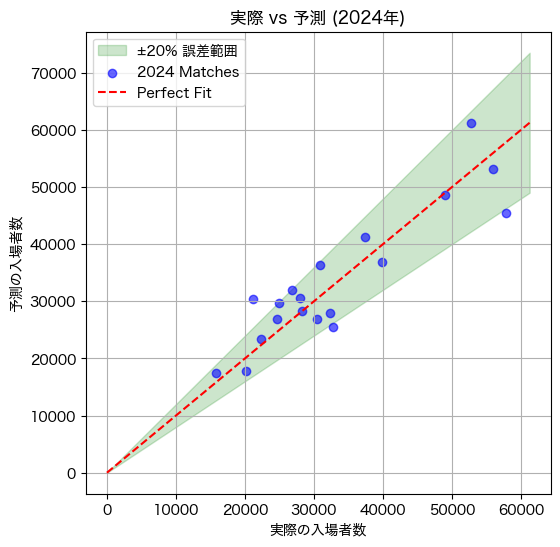

,対戦相手,スタジアム,実測値,予測値,誤差
155,広島,味スタ,32274.0,27982.714165,-4291.285835
156,神戸,味スタ,24974.0,29700.689598,4726.689598
157,浦和,国立,49005.0,48570.800775,-434.199225
158,鹿島,国立,52772.0,61267.113425,8495.113425
159,町田,味スタ,30811.0,36397.619481,5586.619481
160,京都,味スタ,26770.0,31998.369648,5228.369648
161,柏,味スタ,22325.0,23370.060516,1045.060516
162,横浜FM,味スタ,30411.0,26963.590780,-3447.409220
163,Ｇ大阪,味スタ,27972.0,30662.439175,2690.439175
164,磐田,味スタ,24580.0,26853.338878,2273.338878


In [11]:
# ---------------------------------------------------------
# 5. 答え合わせ（可視化）
# ---------------------------------------------------------
# 精度スコアの計算
r2_test = r2_score(y_test, y_pred_2024)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_2024))

print("========================================")
print(f"★ 2024年予測の精度 (R2): {r2_test:.3f}")
print(f"★ 誤差の大きさ (RMSE)  : {rmse_test:,.0f} 人")
print("========================================")

# 散布図で確認
plt.figure(figsize=(6, 6))

# 誤差±20%のエリアを描画
max_val = max(y_test.max(), y_pred_2024.max())
x_line = np.linspace(0, max_val, 100)
plt.fill_between(x_line, x_line * 0.8, x_line * 1.2, 
                 alpha=0.2, color="green", label="±20% 誤差範囲")

plt.scatter(y_test, y_pred_2024, color="blue", alpha=0.6, label="2024 Matches")

# 真ん中の線（ピッタリ賞のライン）
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Fit")

plt.title("実際 vs 予測 (2024年)")
plt.xlabel("実際の入場者数")
plt.ylabel("予測の入場者数")
plt.legend()
plt.grid(True)
plt.show()

# 具体的にどの試合をどう外したか見る
results_df = pd.DataFrame({
    "対戦相手": df.loc[X_test.index, "アウェイ"],
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "実測値": y_test,
    "予測値": y_pred_2024,
    "誤差": y_pred_2024 - y_test
})
display(results_df)

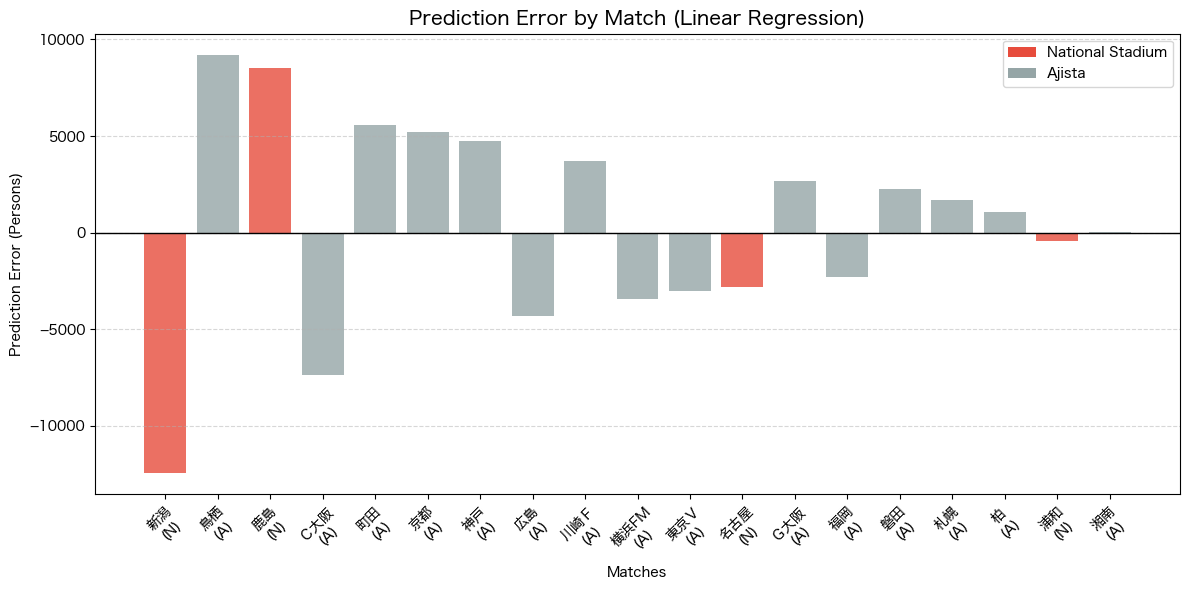

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Hiragino Sans'

# 1. データの準備（前回の続き）
# データフレームを整理します
viz_df = pd.DataFrame({
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "対戦相手": df.loc[X_test.index, "アウェイ"],
    "実測": y_test,
    "予測": y_pred_2024,
    "誤差": y_pred_2024 - y_test  # プラスなら過大評価、マイナスなら過小評価
})

# スタジアム名を簡易化（グラフを見やすくするため）
viz_df["会場タイプ"] = viz_df["スタジアム"].apply(lambda x: "National (Kokuritsu)" if "国立" in x else "Ajista (Regular)")

# -------------------------------------------------------
# 図2：どの試合を外したか一目瞭然（色分け棒グラフ）
# -------------------------------------------------------
# 誤差の絶対値が大きい順に並べる
viz_df_sorted = viz_df.sort_values("誤差", key=abs, ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))

# 棒グラフ（国立は赤、味スタはグレー）
colors = ["#e74c3c" if "国立" in x else "#95a5a6" for x in viz_df_sorted["スタジアム"]]
bars = plt.bar(viz_df_sorted.index, viz_df_sorted["誤差"], color=colors, alpha=0.8)

# 0のライン
plt.axhline(0, color='black', linewidth=1)

# ラベル付け
plt.title("Prediction Error by Match (Linear Regression)", fontsize=14)
plt.xlabel("Matches")
plt.ylabel("Prediction Error (Persons)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# X軸に対戦相手の名前を入れる（混み合うので上位だけ表示してもOK）
plt.xticks(viz_df_sorted.index, viz_df_sorted["対戦相手"] + "\n(" + viz_df_sorted["会場タイプ"].str[:1] + ")", rotation=45)

# 凡例を作る（手動）
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='National Stadium'),
                   Patch(facecolor='#95a5a6', label='Ajista')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [ ]:
# 誤差（絶対値）が大きい順に並べる
worst_predictions = results_df.copy()
worst_predictions["誤差_絶対値"] = worst_predictions["誤差"].abs()

display(worst_predictions.sort_values("誤差_絶対値", ascending=False).head(5))

,対戦相手,スタジアム,実測値,予測値,誤差,誤差_絶対値
167,新潟,国立,57885.0,45428.528184,-12456.471816,12456.471816
171,鳥栖,味スタ,21140.0,30355.428386,9215.428386,9215.428386
158,鹿島,国立,52772.0,61267.113425,8495.113425,8495.113425
173,Ｃ大阪,味スタ,32787.0,25431.277969,-7355.722031,7355.722031
159,町田,味スタ,30811.0,36397.619481,5586.619481,5586.619481


In [ ]:
# スタジアムごとの誤差を見る
analysis_df = pd.DataFrame({
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "実測": y_test,
    "予測": y_pred_2024,
    "誤差(abs)": abs(y_pred_2024 - y_test)
})

# 国立を含むか含まないかでグループ分け
# ※データ内のスタジアム名に合わせて調整してください（例："国立競技場" or "国立"）
is_kokuritsu = analysis_df["スタジアム"].astype(str).str.contains("国立")

rmse_kokuritsu = np.sqrt(mean_squared_error(analysis_df[is_kokuritsu]["実測"], analysis_df[is_kokuritsu]["予測"]))
rmse_ajista = np.sqrt(mean_squared_error(analysis_df[~is_kokuritsu]["実測"], analysis_df[~is_kokuritsu]["予測"]))

print(f"国立競技場のRMSE : {rmse_kokuritsu:,.0f} 人")
print(f"味の素スタジアムのRMSE: {rmse_ajista:,.0f} 人")

国立競技場のRMSE : 7,670 人
味の素スタジアムのRMSE: 4,432 人


### rain_flag追加

In [ ]:
df = pd.read_csv("to_ML.csv")

In [ ]:
df

,シーズン,大会,節,試合日,K/O時刻,ホーム,スコア,アウェイ,スタジアム,入場者数,...,rain_flag,lag1,lag2,rolling_mean_5,rolling_mean_7,rolling_mean_2,home_score,away_score,result_numeric,lag1_result_numeric
0,2015,Ｊ１ １ｓｔ,第２節第２日,15/03/14(土),14:06,FC東京,0-0,横浜FM,味スタ,30492,...,0,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,2015,Ｊ１ １ｓｔ,第４節第２日,15/04/04(土),16:03,FC東京,1-0,甲府,味スタ,20743,...,0,30492.0,NaN,NaN,NaN,25617.5,1,0,1,0.0
2,2015,Ｊ１ １ｓｔ,第６節第２日,15/04/18(土),16:03,FC東京,1-2,広島,味スタ,24369,...,0,20743.0,30492.0,NaN,NaN,22556.0,1,2,0,1.0
3,2015,Ｊ１ １ｓｔ,第９節第１日,15/05/02(土),16:04,FC東京,2-1,川崎Ｆ,味スタ,42604,...,0,24369.0,20743.0,NaN,NaN,33486.5,2,1,1,0.0
4,2015,Ｊ１ １ｓｔ,第１１節第１日,15/05/10(日),16:04,FC東京,0-1,鹿島,味スタ,42070,...,0,42604.0,24369.0,32055.6,NaN,42337.0,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,2024,Ｊ１,第２７節第２日,24/08/17(土),19:03,FC東京,0-0,東京Ｖ,味スタ,39921,...,0,37452.0,57885.0,34243.8,31967.285714,38686.5,0,0,0,0.0
170,2024,Ｊ１,第３０節第２日,24/09/14(土),19:04,FC東京,4-1,名古屋,国立,55896,...,0,39921.0,37452.0,42257.4,35956.428571,47908.5,4,1,1,0.0
171,2024,Ｊ１,第３３節第２日,24/10/05(土),15:03,FC東京,1-1,鳥栖,味スタ,21140,...,1,55896.0,39921.0,42458.8,35465.000000,38518.0,1,1,0,1.0
172,2024,Ｊ１,第３５節第４日,24/11/03(日・祝),14:03,FC東京,0-2,湘南,味スタ,28337,...,0,21140.0,55896.0,36549.2,37252.000000,24738.5,0,2,0,0.0


In [ ]:
# 必要な変数セット
target_cols = ["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_3", "rain_flag"]

# 全データのX
X_all = pd.concat([
    pd.get_dummies(df["アウェイ"], drop_first=True).astype(float),
    df[target_cols].astype(float)
], axis=1).dropna()
X_all = sm.add_constant(X_all)

# 全データのy
y_all = df.loc[X_all.index,"入場者数"].astype(float)

In [ ]:
train_mask = df.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == False
test_mask = df.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == True

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}(2024年試合数)")

学習データ数: 153
テストデータ数: 19(2024年試合数)


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIFを計算する関数
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    
    # 各変数のVIFを計算
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    
    return vif_data.sort_values("VIF", ascending=False)

# 定数項（const）が含まれているXを使って計算
vif_df = calculate_vif(X_train)
print(vif_df)

           feature         VIF
0            const  125.378493
7               広島    5.907263
26              鹿島    5.903760
25              鳥栖    5.888925
16              浦和    5.862299
22              神戸    5.655272
6              川崎Ｆ    5.647634
28             Ｇ大阪    5.636129
2              名古屋    5.385564
13               柏    5.380493
15            横浜FM    5.378212
18              湘南    5.358916
10              札幌    4.916950
27             Ｃ大阪    4.901162
17              清水    4.855266
1               仙台    4.848381
32  rolling_mean_3    4.466460
29         コロナ禍ダミー    4.105676
21              磐田    3.779074
9               新潟    3.269552
23              福岡    3.233242
14            横浜FC    2.748104
3               大分    2.736172
19              甲府    2.157813
12              松本    2.153623
4               大宮    2.140912
24              長崎    1.642440
8               徳島    1.615184
5               山形    1.572511
31           休日フラグ    1.347913
30           国立フラグ    1.332985
33      

/Users/tasskkiu2/myproject/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [ ]:
# 学習
model_step1 = sm.OLS(y_train, X_train).fit()

# 予測
y_pred_2024 = model_step1.predict(X_test)

★ 2024年予測の精度 (R2): 0.840
★ 誤差の大きさ (RMSE)  : 4,859 人


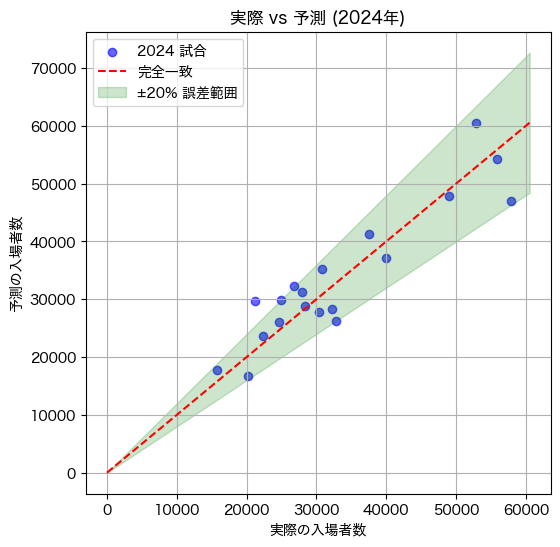

,対戦相手,スタジアム,実測値,予測値,誤差
155,広島,味スタ,32274.0,28256.591475,-4017.408525
156,神戸,味スタ,24974.0,29940.319164,4966.319164
157,浦和,国立,49005.0,47795.867527,-1209.132473
158,鹿島,国立,52772.0,60522.811979,7750.811979
159,町田,味スタ,30811.0,35207.365865,4396.365865
160,京都,味スタ,26770.0,32289.832341,5519.832341
161,柏,味スタ,22325.0,23714.065681,1389.065681
162,横浜FM,味スタ,30411.0,27810.038304,-2600.961696
163,Ｇ大阪,味スタ,27972.0,31306.364982,3334.364982
164,磐田,味スタ,24580.0,25977.433089,1397.433089


In [ ]:
# ---------------------------------------------------------
# 5. 答え合わせ（可視化）
# ---------------------------------------------------------
# 精度スコアの計算
r2_test = r2_score(y_test, y_pred_2024)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_2024))

print("========================================")
print(f"★ 2024年予測の精度 (R2): {r2_test:.3f}")
print(f"★ 誤差の大きさ (RMSE)  : {rmse_test:,.0f} 人")
print("========================================")

# 散布図で確認
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_2024, color="blue", alpha=0.6, label="2024 試合")

# 真ん中の線（ピッタリ賞のライン）
max_val = max(y_test.max(), y_pred_2024.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="完全一致")

# 誤差±20%のエリアを描画
max_val = max(y_test.max(), y_pred_2024.max())
x_line = np.linspace(0, max_val, 100)
plt.fill_between(x_line, x_line * 0.8, x_line * 1.2, 
                 alpha=0.2, color="green", label="±20% 誤差範囲")


plt.title("実際 vs 予測 (2024年)")
plt.xlabel("実際の入場者数")
plt.ylabel("予測の入場者数")
plt.legend()
plt.grid(True)
plt.show()

# 具体的にどの試合をどう外したか見る
results_df = pd.DataFrame({
    "対戦相手": df.loc[X_test.index, "アウェイ"],
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "実測値": y_test,
    "予測値": y_pred_2024,
    "誤差": y_pred_2024 - y_test
})
display(results_df)

In [ ]:
print(model_step1.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     21.03
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           1.91e-35
Time:                        20:08:45   Log-Likelihood:                -1514.0
No. Observations:                 153   AIC:                             3092.
Df Residuals:                     121   BIC:                             3189.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4329.6816   4885.276      0.

In [ ]:
# スタジアムごとの誤差を見る
analysis_df = pd.DataFrame({
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "実測": y_test,
    "予測": y_pred_2024,
    "誤差(abs)": abs(y_pred_2024 - y_test)
})

# 国立を含むか含まないかでグループ分け
# ※データ内のスタジアム名に合わせて調整してください（例："国立競技場" or "国立"）
is_kokuritsu = analysis_df["スタジアム"].astype(str).str.contains("国立")

rmse_kokuritsu = np.sqrt(mean_squared_error(analysis_df[is_kokuritsu]["実測"], analysis_df[is_kokuritsu]["予測"]))
rmse_ajista = np.sqrt(mean_squared_error(analysis_df[~is_kokuritsu]["実測"], analysis_df[~is_kokuritsu]["予測"]))

print(f"国立競技場のRMSE : {rmse_kokuritsu:,.0f} 人")
print(f"味の素スタジアムのRMSE: {rmse_ajista:,.0f} 人")

国立競技場のRMSE : 6,768 人
味の素スタジアムのRMSE: 4,206 人


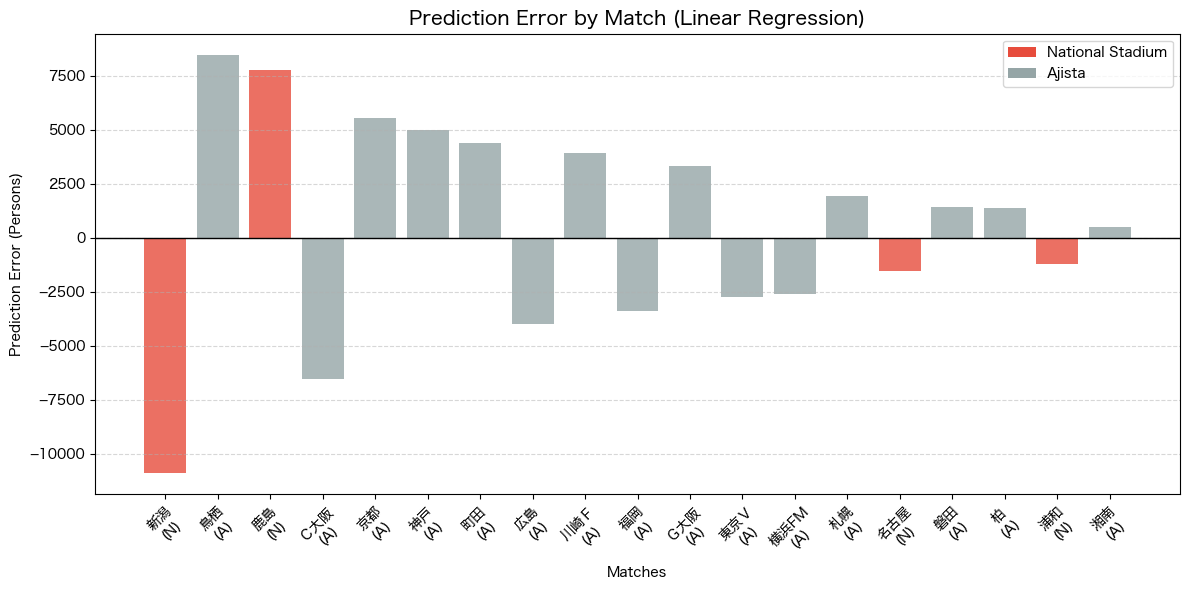

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Hiragino Sans'

# 1. データの準備（前回の続き）
# データフレームを整理します
viz_df = pd.DataFrame({
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "対戦相手": df.loc[X_test.index, "アウェイ"],
    "実測": y_test,
    "予測": y_pred_2024,
    "誤差": y_pred_2024 - y_test  # プラスなら過大評価、マイナスなら過小評価
})

# スタジアム名を簡易化（グラフを見やすくするため）
viz_df["会場タイプ"] = viz_df["スタジアム"].apply(lambda x: "National (Kokuritsu)" if "国立" in x else "Ajista (Regular)")

# -------------------------------------------------------
# 図2：どの試合を外したか一目瞭然（色分け棒グラフ）
# -------------------------------------------------------
# 誤差の絶対値が大きい順に並べる
viz_df_sorted = viz_df.sort_values("誤差", key=abs, ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))

# 棒グラフ（国立は赤、味スタはグレー）
colors = ["#e74c3c" if "国立" in x else "#95a5a6" for x in viz_df_sorted["スタジアム"]]
bars = plt.bar(viz_df_sorted.index, viz_df_sorted["誤差"], color=colors, alpha=0.8)

# 0のライン
plt.axhline(0, color='black', linewidth=1)

# ラベル付け
plt.title("Prediction Error by Match (Linear Regression)", fontsize=14)
plt.xlabel("Matches")
plt.ylabel("Prediction Error (Persons)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# X軸に対戦相手の名前を入れる（混み合うので上位だけ表示してもOK）
plt.xticks(viz_df_sorted.index, viz_df_sorted["対戦相手"] + "\n(" + viz_df_sorted["会場タイプ"].str[:1] + ")", rotation=45)

# 凡例を作る（手動）
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='National Stadium'),
                   Patch(facecolor='#95a5a6', label='Ajista')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### アウェイ削除

In [ ]:
# 必要な変数セット
target_cols = ["コロナ禍ダミー","国立フラグ","休日フラグ","rolling_mean_3"]

# 全データのX
X_all = pd.concat([
    df[target_cols].astype(float)
], axis=1).dropna()
X_all = sm.add_constant(X_all)

# 全データのy
y_all = df.loc[X_all.index,"入場者数"].astype(float)

train_mask = df.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == False
test_mask = df.loc[X_all.index,"シーズン"].astype(str).str.contains("2024") == True

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]


model = sm.OLS(y_train,X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     108.5
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           5.54e-43
Time:                        09:43:56   Log-Likelihood:                -1551.1
No. Observations:                 153   AIC:                             3112.
Df Residuals:                     148   BIC:                             3127.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3076.0408   2724.778      1.

### シミュレーション

In [13]:
# ---------------------------------------------------------
# STEP 2: "What-If" シミュレーション
# 〜 もし、あの試合が国立だったら？ 〜
# ---------------------------------------------------------

# モデルは「全データ」で学習させた最強の状態のものを使います
# （さっきの model_step1 ではなく、前のステップで作った model を推奨）
# もし手元になければ、もう一度全データで fit してください
model = sm.OLS(y_all, X_all).fit() 

# 仮想データの作成
# 例：対戦相手は「広島（そこそこ強いがcoefは低め）」と仮定
# 変数の名前はご自身の X.columns に合わせてください

# パターンA：【絶望】水曜ナイター、雨、味スタ、直近3試合は不調(2万人)
# パターンB：【希望】土曜・快晴、国立、直近3試合は絶好調(4万人)

# ※注意: ダミー変数の列名は get_dummies の結果に合わせて調整が必要です
# 以下のコードは自動で列を埋める関数です

def create_simulation_data(base_X, opponent_name, is_holiday, is_national, rolling_3):
    # ベースとなる空の行（全部0）を作る
    sim_row = pd.DataFrame(0, index=[0], columns=base_X.columns)
    
    # 1. 定数項
    sim_row["const"] = 1.0
    
    # 2. 対戦相手フラグを立てる (列名が存在する場合のみ)
    col_name = opponent_name  # "広島" または "アウェイ_広島" など
    if col_name in sim_row.columns:
        sim_row[col_name] = 1.0
    else:
        print(f"Warning: {col_name} が見つかりません。基準チームとして扱います。")

    # 3. 条件セット
    sim_row["休日フラグ"] = 1.0 if is_holiday else 0.0
    sim_row["国立フラグ"] = 1.0 if is_national else 0.0
    sim_row["rolling_mean_3"] = rolling_3
    
    # コロナは当然なし
    sim_row["コロナ禍ダミー"] = 0.0
    
    return sim_row

# ---- シミュレーション実行 ----

# 使うモデル（全データ学習済み）
target_model = model  # さっきR2=0.855を出したモデル

# 仮想敵：サンフレッチェ広島（アウェイ_広島）で実験
# ※列名が "広島" か "アウェイ_広島" か確認してください
target_team = "広島"

# シナリオ1: 平日・味スタ・チーム不調（直近2万）
sim_bad = create_simulation_data(X_all, target_team, is_holiday=False, is_national=False, rolling_3=20000)

# シナリオ2: 休日・国立・チーム好調（直近4万）
sim_good = create_simulation_data(X_all, target_team, is_holiday=True, is_national=True, rolling_3=40000)

# 予測
pred_bad = target_model.predict(sim_bad)[0]
pred_good = target_model.predict(sim_good)[0]

print(f"対戦相手: {target_team}")
print("-" * 30)
print(f"【シナリオA：日常】平日・味スタ・不調\n  => 予測観客数: {pred_bad:,.0f} 人")
print("-" * 30)
print(f"【シナリオB：イベント】休日・国立・好調\n  => 予測観客数: {pred_good:,.0f} 人")
print("-" * 30)
print(f"差分（集客ポテンシャル）: +{pred_good - pred_bad:,.0f} 人")

対戦相手: 広島
------------------------------
【シナリオA：日常】平日・味スタ・不調
  => 予測観客数: 16,237 人
------------------------------
【シナリオB：イベント】休日・国立・好調
  => 予測観客数: 53,056 人
------------------------------
差分（集客ポテンシャル）: +36,819 人


In [16]:
model = sm.OLS(y_all, X_all).fit() 
def create_simulation_data(base_X, opponent_name, is_holiday, is_national, rolling_3):
    # ベースとなる空の行（全部0）を作る
    sim_row = pd.DataFrame(0, index=[0], columns=base_X.columns)
    
    # 1. 定数項
    sim_row["const"] = 1.0
    
    # 2. 対戦相手フラグを立てる (列名が存在する場合のみ)
    col_name = opponent_name  # "広島" または "アウェイ_広島" など
    if col_name in sim_row.columns:
        sim_row[col_name] = 1.0
    else:
        print(f"Warning: {col_name} が見つかりません。基準チームとして扱います。")

    # 3. 条件セット
    sim_row["休日フラグ"] = 1.0 if is_holiday else 0.0
    sim_row["国立フラグ"] = 1.0 if is_national else 0.0
    sim_row["rolling_mean_3"] = rolling_3
    
    # コロナは当然なし
    sim_row["コロナ禍ダミー"] = 0.0
    
    return sim_row

# ---- シミュレーション実行 ----

# 使うモデル（全データ学習済み）
target_model = model  # さっきR2=0.855を出したモデル

# 仮想敵：サンフレッチェ広島（アウェイ_広島）で実験
# ※列名が "広島" か "アウェイ_広島" か確認してください
target_team = "浦和" if "浦和" in X_all.columns else "アウェイ_広島"

# シナリオ1: 平日・味スタ・チーム平均（直近2万5000）
sim_bad = create_simulation_data(X_all, "広島", is_holiday=True, is_national=False, rolling_3=25000)

# シナリオ2: 休日・国立・チーム平均（直近3万）
sim_good = create_simulation_data(X_all, "浦和", is_holiday=True, is_national=True, rolling_3=30000)

# 予測
pred_bad = target_model.predict(sim_bad)[0]
pred_good = target_model.predict(sim_good)[0]


print("-" * 30)
print(f"【シナリオA：日常】休日・味スタ・平均\n  => 予測観客数: {pred_bad:,.0f} 人")
print("-" * 30)
print(f"【シナリオB：イベント】休日・国立・平均\n  => 予測観客数: {pred_good:,.0f} 人")
print("-" * 30)
print(f"差分（集客ポテンシャル）: +{pred_good - pred_bad:,.0f} 人")

------------------------------
【シナリオA：日常】休日・味スタ・平均
  => 予測観客数: 25,395 人
------------------------------
【シナリオB：イベント】休日・国立・平均
  => 予測観客数: 53,057 人
------------------------------
差分（集客ポテンシャル）: +27,663 人


### RF

R2: 0.826
RMSE: 5,068 人


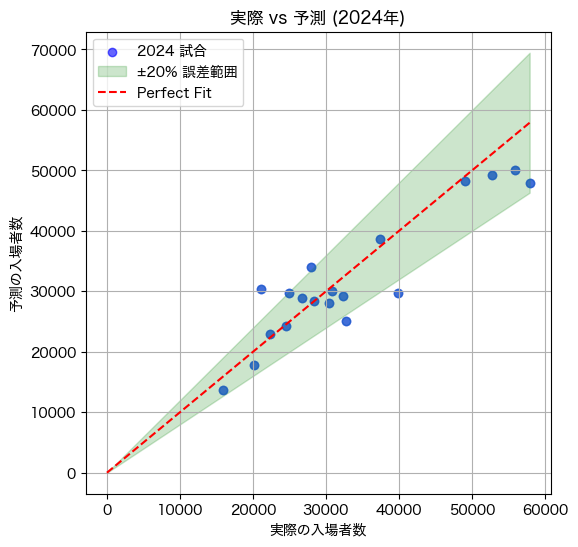

In [ ]:
# RF
from sklearn.ensemble import RandomForestRegressor

# モデルの初期化
rf_model = RandomForestRegressor(
    n_estimators=100,  # 決定木の数
    random_state=42,  # 再現性のためのシャッフルシード
    n_jobs=-1  # 並列処理数
)

# モデルの学習
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# モデルの評価
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"R2: {rf_r2:.3f}")
print(f"RMSE: {rf_rmse:,.0f} 人")

# 予測結果の可視化
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, color="blue", alpha=0.6, label="2024 試合")

# 誤差±20%のエリアを描画
max_val = max(y_test.max(), rf_pred.max())
x_line = np.linspace(0, max_val, 100)
plt.fill_between(x_line, x_line * 0.8, x_line * 1.2, 
                 alpha=0.2, color="green", label="±20% 誤差範囲")

plt.scatter(y_test, rf_pred, alpha=0.5)
# 真ん中の線（ピッタリ賞のライン）
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Fit")

plt.title("実際 vs 予測 (2024年)")
plt.xlabel("実際の入場者数")
plt.ylabel("予測の入場者数")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# スタジアムごとの誤差を見る,RF version
analysis_df = pd.DataFrame({
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "実測": y_test,
    "予測": rf_pred,
    "誤差(abs)": abs(rf_pred - y_test)
})

# 国立を含むか含まないかでグループ分け
# ※データ内のスタジアム名に合わせて調整してください（例："国立競技場" or "国立"）
is_kokuritsu = analysis_df["スタジアム"].astype(str).str.contains("国立")

rmse_kokuritsu = np.sqrt(mean_squared_error(analysis_df[is_kokuritsu]["実測"], analysis_df[is_kokuritsu]["予測"]))
rmse_ajista = np.sqrt(mean_squared_error(analysis_df[~is_kokuritsu]["実測"], analysis_df[~is_kokuritsu]["予測"]))

print(f"国立競技場のRMSE : {rmse_kokuritsu:,.0f} 人")
print(f"味の素スタジアムのRMSE: {rmse_ajista:,.0f} 人")

国立競技場のRMSE : 6,810 人
味の素スタジアムのRMSE: 4,807 人


In [ ]:
# Random Forest（ハイパーパラメータ調整版）
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ハイパーパラメータのグリッド
param_grid = {
    'n_estimators': [50, 100, 200, 300],      # 決定木の数
    'max_depth': [None, 5, 10, 15, 20],       # 木の深さ
    'min_samples_split': [2, 5, 10],          # 分割に必要な最小サンプル数
    'min_samples_leaf': [1, 2, 4],            # 葉ノードの最小サンプル数
    'max_features': ['sqrt', 'log2', None]    # 分割時に使用する特徴量数
}

# RandomizedSearchCVで効率的に探索（全組み合わせは多すぎるため）
rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    rf, 
    param_distributions=param_grid, 
    n_iter=50,           # 50パターンをランダムに試行
    cv=5, 
    scoring='r2', 
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("ハイパーパラメータ探索中...")
random_search.fit(X_train, y_train)

print(f"\n最適なパラメータ:")
for key, value in random_search.best_params_.items():
    print(f"  {key}: {value}")
print(f"\nクロスバリデーションスコア (R2): {random_search.best_score_:.3f}")

# 最適なモデルで予測
rf_best = random_search.best_estimator_
rf_tuned_pred = rf_best.predict(X_test)

# モデルの評価
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))

print(f"\n========================================")
print(f"★ Random Forest（チューニング済） 2024年予測の精度 (R2): {rf_tuned_r2:.3f}")
print(f"★ 誤差の大きさ (RMSE): {rf_tuned_rmse:,.0f} 人")
print(f"========================================")

ハイパーパラメータ探索中...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

最適なパラメータ:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: None

クロスバリデーションスコア (R2): 0.603

★ Random Forest（チューニング済） 2024年予測の精度 (R2): 0.703
★ 誤差の大きさ (RMSE): 6,618 人


### Lasso回帰

In [ ]:
# df生成
df = pd.read_csv("to_ML.csv")

最適なalpha: 1105582.0825

★ Lasso回帰 2024年予測の精度 (R2): -0.822
★ 誤差の大きさ (RMSE): 16,402 人

【Lasso回帰の係数（重要度順）】
           特徴量       係数  係数(絶対値)
rolling_mean_3 0.984861 0.984861

係数がゼロになった特徴量の数: 33


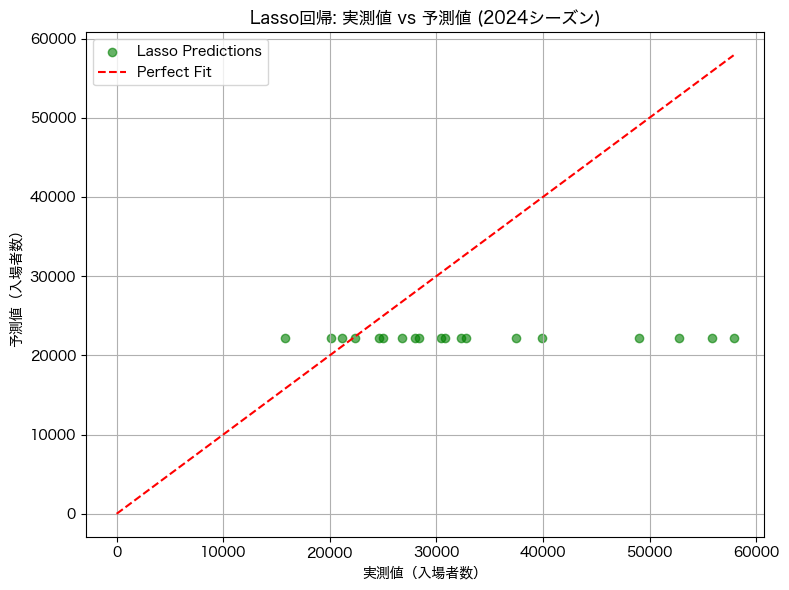


【モデル比較】
OLS線形回帰   - R2: 0.840, RMSE: 4,859 人
Lasso回帰     - R2: -0.822, RMSE: 16,402 人


In [ ]:
# Lasso回帰
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# 最適なalphaをクロスバリデーションで探索
lasso_cv = LassoCV(alphas=None, cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

print(f"最適なalpha: {lasso_cv.alpha_:.4f}")
# Xの標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# パイプラインを作成
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=lasso_cv.alpha_, random_state=42))
])

# パイプラインを使ってモデルを学習
pipeline.fit(X_train, y_train)

# 予測
lasso_pred = pipeline.predict(X_test)

# モデルの評価
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print(f"\n========================================")
print(f"★ Lasso回帰 2024年予測の精度 (R2): {lasso_r2:.3f}")
print(f"★ 誤差の大きさ (RMSE): {lasso_rmse:,.0f} 人")
print(f"========================================")

# 係数の確認（特徴量選択の効果を見る）
coef_df = pd.DataFrame({
    '特徴量': X_train.columns,
    '係数': lasso_model.coef_
})
coef_df['係数(絶対値)'] = abs(coef_df['係数'])
coef_df = coef_df.sort_values('係数(絶対値)', ascending=False)

print("\n【Lasso回帰の係数（重要度順）】")
print(coef_df[coef_df['係数'] != 0].to_string(index=False))
print(f"\n係数がゼロになった特徴量の数: {(coef_df['係数'] == 0).sum()}")

# 予測結果の可視化
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lasso_pred, alpha=0.6, color='green', label='Lasso Predictions')

# 完璧な予測ライン
max_val = max(y_test.max(), lasso_pred.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Fit")

plt.title("Lasso回帰: 実測値 vs 予測値 (2024シーズン)")
plt.xlabel("実測値（入場者数）")
plt.ylabel("予測値（入場者数）")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 各モデルの比較
print("\n【モデル比較】")
print(f"OLS線形回帰   - R2: {r2_test:.3f}, RMSE: {rmse_test:,.0f} 人")
print(f"Lasso回帰     - R2: {lasso_r2:.3f}, RMSE: {lasso_rmse:,.0f} 人")

### Ridge回帰

In [ ]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# 最適なalphaをクロスバリデーションで探索
alphas = np.logspace(-3, 3, 100)  # 0.001 ~ 1000
ridge_cv = RidgeCV(alphas=alphas, cv=5)

# 最適なalphaを探索
ridge_cv.fit(X_train, y_train)

print(f"最適なalpha: {ridge_cv.alpha_:.4f}")

# Xの標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# パイプラインを作成
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=ridge_cv.alpha_, random_state=42))
])

# パイプラインを使ってモデルを学習
pipeline.fit(X_train, y_train)

# 予測
ridge_pred = pipeline.predict(X_test)

# モデルの評価
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print(f"\n========================================")
print(f"★ Ridge回帰 2024年予測の精度 (R2): {ridge_r2:.3f}")
print(f"★ 誤差の大きさ (RMSE): {ridge_rmse:,.0f} 人")
print(f"========================================")

最適なalpha: 8.6975

★ Ridge回帰 2024年予測の精度 (R2): 0.840
★ 誤差の大きさ (RMSE): 4,858 人


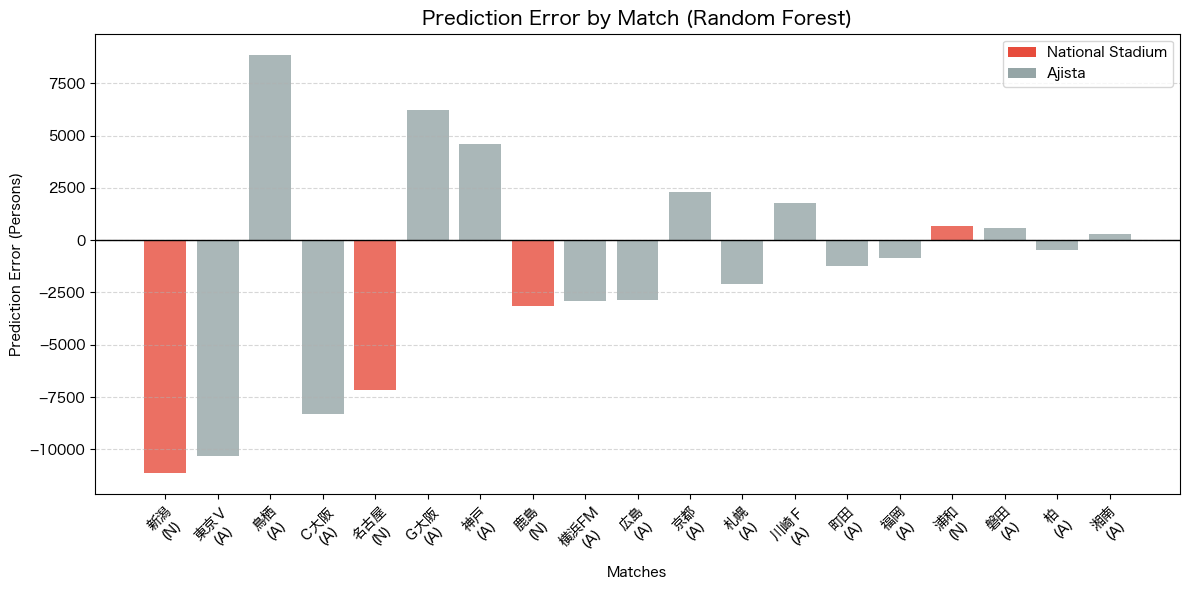

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Hiragino Sans'

# 1. データの準備（前回の続き）
# データフレームを整理します
viz_df = pd.DataFrame({
    "スタジアム": df.loc[X_test.index, "スタジアム"],
    "対戦相手": df.loc[X_test.index, "アウェイ"],
    "実測": y_test,
    "予測": rf_pred,
    "誤差": rf_pred - y_test  # プラスなら過大評価、マイナスなら過小評価
})

# スタジアム名を簡易化（グラフを見やすくするため）
viz_df["会場タイプ"] = viz_df["スタジアム"].apply(lambda x: "National (Kokuritsu)" if "国立" in x else "Ajista (Regular)")

# -------------------------------------------------------
# 図2：どの試合を外したか一目瞭然（色分け棒グラフ）
# -------------------------------------------------------
# 誤差の絶対値が大きい順に並べる
viz_df_sorted = viz_df.sort_values("誤差", key=abs, ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))

# 棒グラフ（国立は赤、味スタはグレー）
colors = ["#e74c3c" if "国立" in x else "#95a5a6" for x in viz_df_sorted["スタジアム"]]
bars = plt.bar(viz_df_sorted.index, viz_df_sorted["誤差"], color=colors, alpha=0.8)

# 0のライン
plt.axhline(0, color='black', linewidth=1)

# ラベル付け
plt.title("Prediction Error by Match (Random Forest)", fontsize=14)
plt.xlabel("Matches")
plt.ylabel("Prediction Error (Persons)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# X軸に対戦相手の名前を入れる（混み合うので上位だけ表示してもOK）
plt.xticks(viz_df_sorted.index, viz_df_sorted["対戦相手"] + "\n(" + viz_df_sorted["会場タイプ"].str[:1] + ")", rotation=45)

# 凡例を作る（手動）
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='National Stadium'),
                   Patch(facecolor='#95a5a6', label='Ajista')]
plt.legend(handles=legend_elements)

plt.tight_layout()

### SVR

最適なパラメータ: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
クロスバリデーションスコア (R2): 0.150

★ SVR 2024年予測の精度 (R2): 0.812
★ 誤差の大きさ (RMSE): 5,275 人


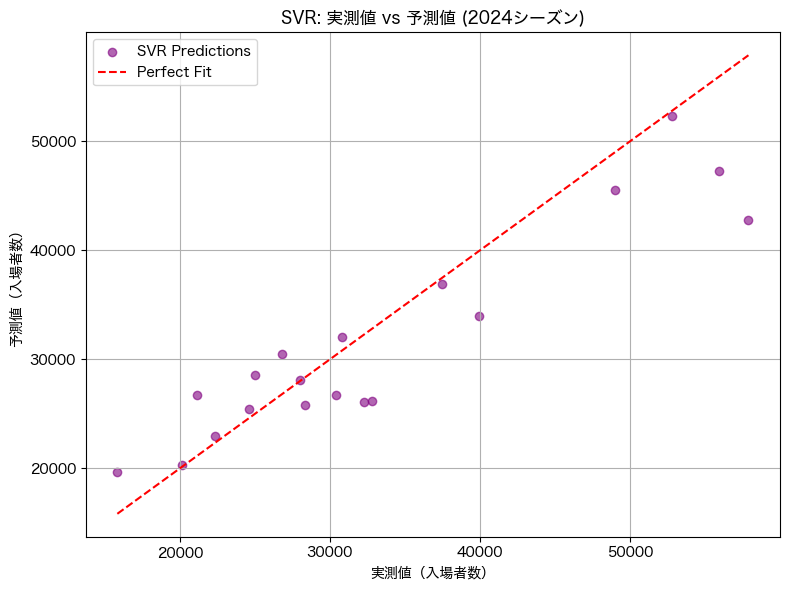


【全モデル比較】
OLS線形回帰   - R2: 0.840, RMSE: 4,859 人
Random Forest - R2: 0.826, RMSE: 5,068 人
Lasso回帰     - R2: -0.822, RMSE: 16,402 人
SVR          - R2: 0.812, RMSE: 5,275 人


In [ ]:
# SVR（Support Vector Regression）
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# SVRはスケーリングが重要
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ハイパーパラメータのグリッドサーチ
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

svr = SVR()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"最適なパラメータ: {grid_search.best_params_}")
print(f"クロスバリデーションスコア (R2): {grid_search.best_score_:.3f}")

# 最適なモデルで予測
svr_best = grid_search.best_estimator_
svr_pred = svr_best.predict(X_test_scaled)

# モデルの評価
svr_r2 = r2_score(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))

print(f"\n========================================")
print(f"★ SVR 2024年予測の精度 (R2): {svr_r2:.3f}")
print(f"★ 誤差の大きさ (RMSE): {svr_rmse:,.0f} 人")
print(f"========================================")

# 予測結果の可視化
plt.figure(figsize=(8, 6))
plt.scatter(y_test, svr_pred, alpha=0.6, color='purple', label='SVR Predictions')

# 完璧な予測ライン
max_val = max(y_test.max(), svr_pred.max())
min_val = min(y_test.min(), svr_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Fit")

plt.title("SVR: 実測値 vs 予測値 (2024シーズン)")
plt.xlabel("実測値（入場者数）")
plt.ylabel("予測値（入場者数）")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 全モデル比較
print("\n【全モデル比較】")
print(f"OLS線形回帰   - R2: {r2_test:.3f}, RMSE: {rmse_test:,.0f} 人")
print(f"Random Forest - R2: {rf_r2:.3f}, RMSE: {rf_rmse:,.0f} 人")
print(f"Lasso回帰     - R2: {lasso_r2:.3f}, RMSE: {lasso_rmse:,.0f} 人")
print(f"SVR          - R2: {svr_r2:.3f}, RMSE: {svr_rmse:,.0f} 人")

### モデルの比較

In [ ]:
# 全モデル比較
print("\n【全モデル比較】")
print(f"OLS線形回帰              - R2: {r2_test:.3f}, RMSE: {rmse_test:,.0f} 人")
print(f"Lasso回帰                - R2: {lasso_r2:.3f}, RMSE: {lasso_rmse:,.0f} 人")
print(f"Ridge回帰                - R2: {ridge_r2:.3f}, RMSE: {ridge_rmse:,.0f} 人")
print(f"SVR                      - R2: {svr_r2:.3f}, RMSE: {svr_rmse:,.0f} 人")
print(f"Random Forest (チューニングなし) - R2  {rf_r2:.3f}, RMSE: {rf_rmse:,.0f} 人",)
print(f"Random Forest（チューニング済） - R2: {rf_tuned_r2:.3f}, RMSE: {rf_tuned_rmse:,.0f} 人")


【全モデル比較】
OLS線形回帰              - R2: 0.840, RMSE: 4,859 人
Lasso回帰                - R2: -0.822, RMSE: 16,402 人
Ridge回帰                - R2: 0.840, RMSE: 4,858 人
SVR                      - R2: 0.812, RMSE: 5,275 人
Random Forest (チューニングなし) - R2  0.826, RMSE: 5,068 人
Random Forest（チューニング済） - R2: 0.703, RMSE: 6,618 人
